In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Plot Settings

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

Load Cleaned Dataset

In [5]:
df = pd.read_csv("cleaned_loan_data.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (218832, 40)


Basic Data Overview

In [6]:
print("\nDataset Info")
print(df.info())

print("\nStatistical Summary")
print(df.describe())


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218832 entries, 0 to 218831
Data columns (total 40 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   loan_amnt                            218832 non-null  int64  
 1   term                                 218832 non-null  int64  
 2   int_rate                             218832 non-null  float64
 3   installment                          218832 non-null  float64
 4   emp_length                           218832 non-null  float64
 5   annual_inc                           218832 non-null  float64
 6   dti                                  218832 non-null  float64
 7   delinq_2yrs                          218832 non-null  float64
 8   revol_util                           218832 non-null  float64
 9   total_acc                            218832 non-null  float64
 10  loan_status                          218832 non-null  int64  
 11 

Check Class Distribution (Default vs Non-default)

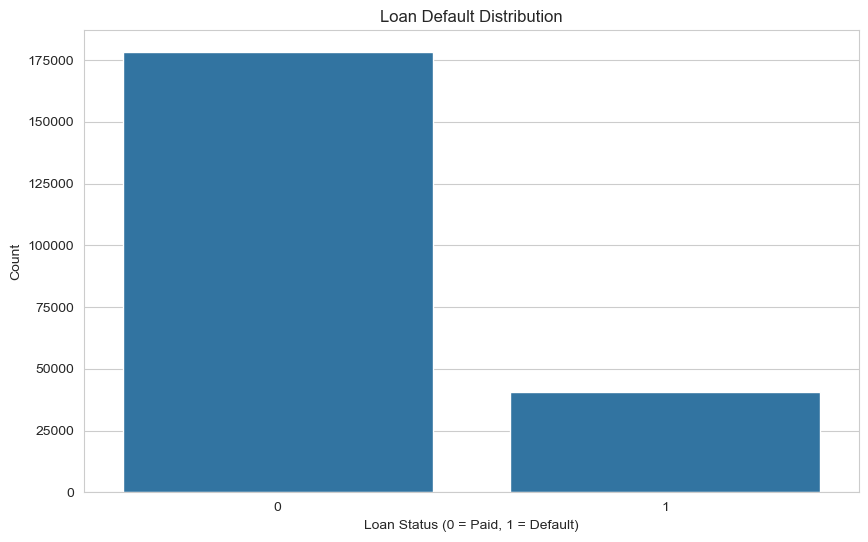


Default Rate: 18.6 %


In [7]:
plt.figure()
sns.countplot(x="loan_status", data=df)
plt.title("Loan Default Distribution")
plt.xlabel("Loan Status (0 = Paid, 1 = Default)")
plt.ylabel("Count")
plt.show()

default_rate = df["loan_status"].mean()
print("\nDefault Rate:", round(default_rate * 100, 2), "%")

Correlation Analysis

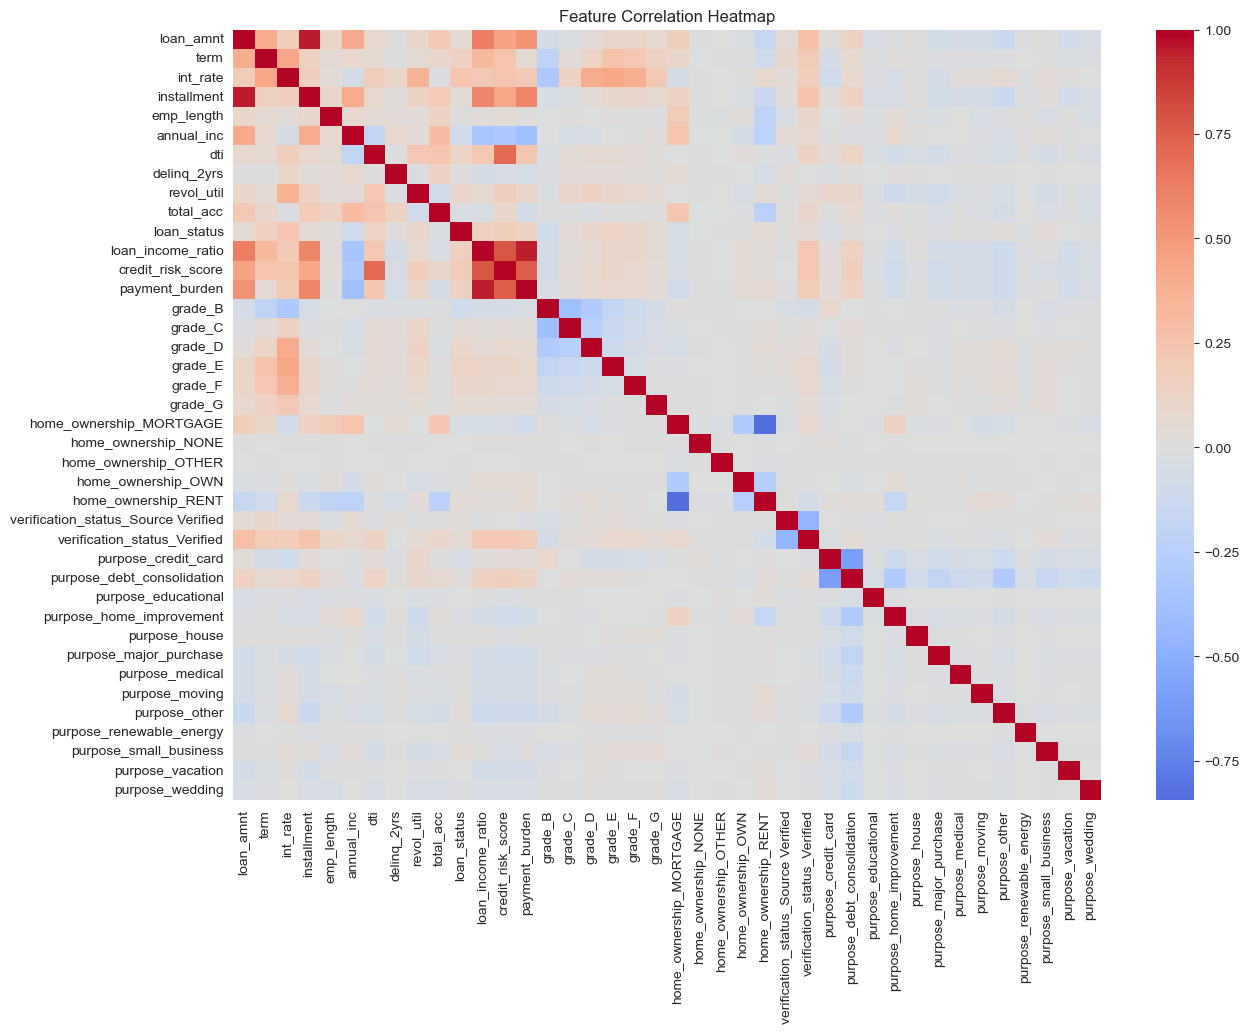

In [8]:
plt.figure(figsize=(14,10))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

Income vs Loan Amount Analysis

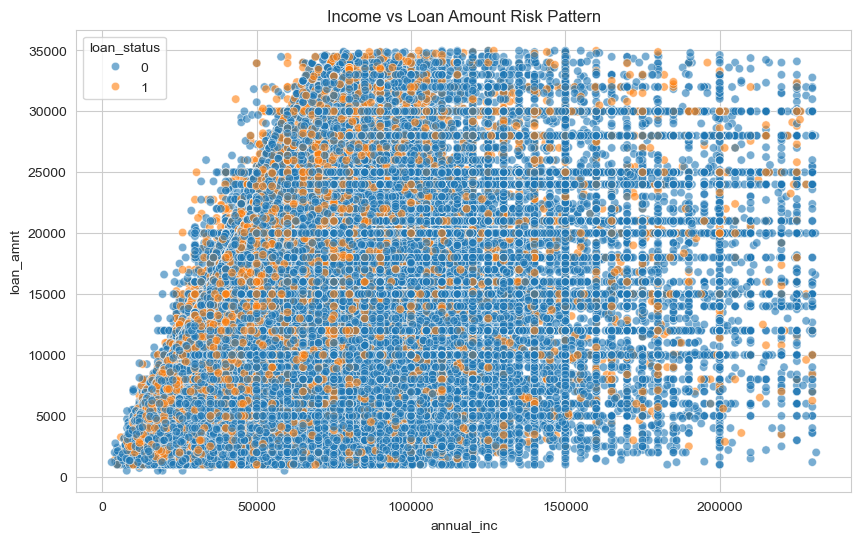

In [9]:
plt.figure()
sns.scatterplot(
    x="annual_inc",
    y="loan_amnt",
    hue="loan_status",
    data=df,
    alpha=0.6
)
plt.title("Income vs Loan Amount Risk Pattern")
plt.show()

Debt-to-Income Risk Analysis

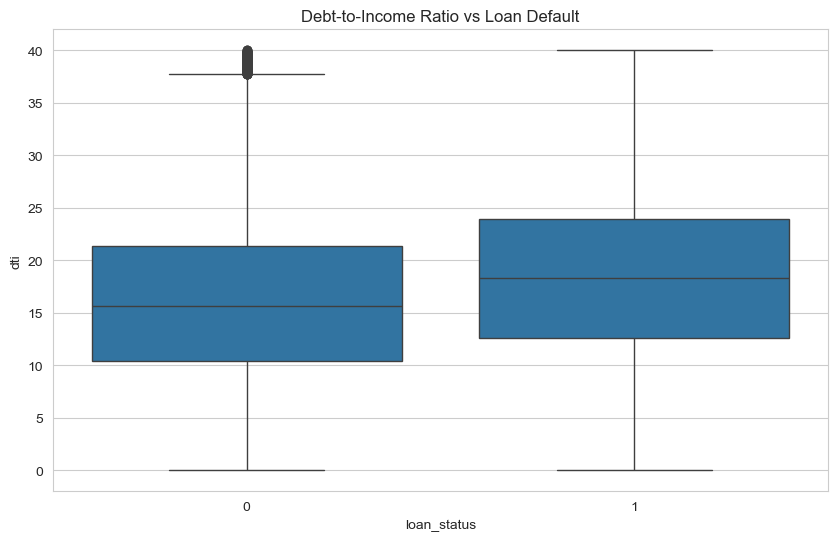

In [10]:
plt.figure()
sns.boxplot(
    x="loan_status",
    y="dti",
    data=df
)
plt.title("Debt-to-Income Ratio vs Loan Default")
plt.show()

Loan Amount Distribution

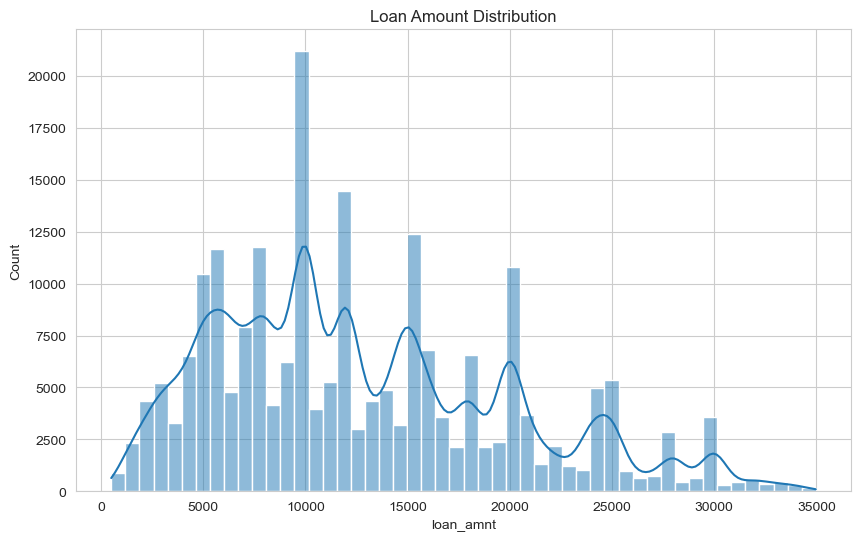

In [13]:
plt.figure()
sns.histplot(df["loan_amnt"], bins=50, kde=True)
plt.title("Loan Amount Distribution")
plt.show()

Interest Rate Risk Analysis

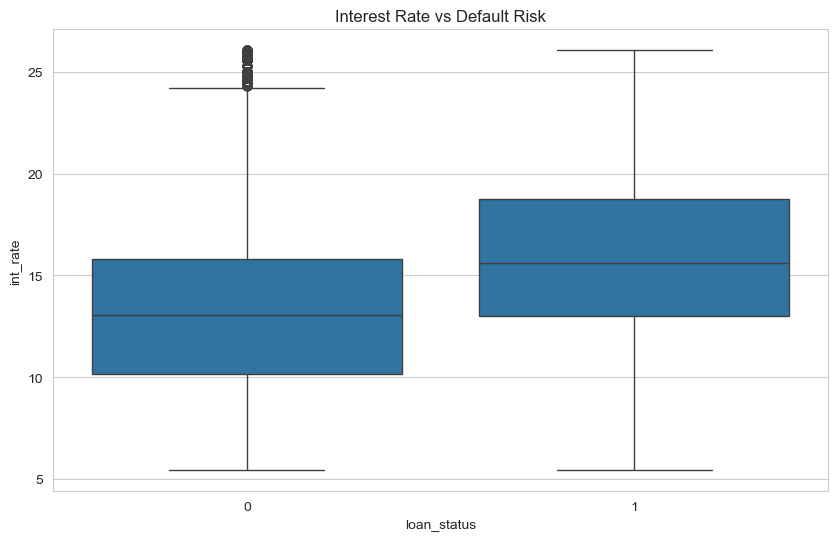

In [14]:
plt.figure()
sns.boxplot(
    x="loan_status",
    y="int_rate",
    data=df
)
plt.title("Interest Rate vs Default Risk")
plt.show()

Employment Length Impact

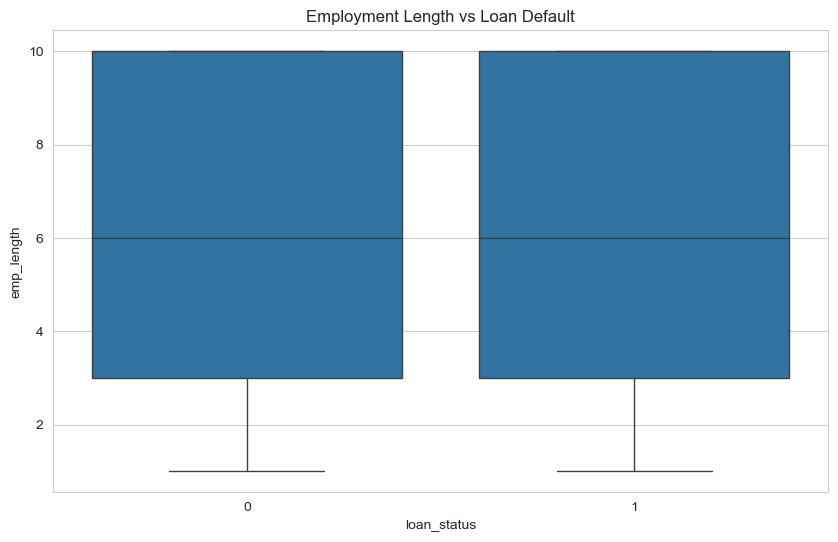

In [15]:
plt.figure()
sns.boxplot(
    x="loan_status",
    y="emp_length",
    data=df
)
plt.title("Employment Length vs Loan Default")
plt.show()

Feature Importance Preview (Correlation with Target)

In [17]:
target_corr = df.corr()["loan_status"].sort_values(ascending=False)

print("\nTop Risk Indicators:")
print(target_corr.head(10))

print("\nTop Safe Indicators:")
print(target_corr.tail(10))


Top Risk Indicators:
loan_status          1.000000
int_rate             0.243867
credit_risk_score    0.172529
term                 0.162337
loan_income_ratio    0.154443
payment_burden       0.137302
dti                  0.116972
grade_E              0.116476
grade_D              0.096416
grade_F              0.095438
Name: loan_status, dtype: float64

Top Safe Indicators:
purpose_vacation           -0.000928
purpose_educational        -0.001554
purpose_wedding            -0.012679
purpose_home_improvement   -0.016159
purpose_major_purchase     -0.019269
total_acc                  -0.029096
purpose_credit_card        -0.031350
home_ownership_MORTGAGE    -0.049169
annual_inc                 -0.094722
grade_B                    -0.095864
Name: loan_status, dtype: float64


Risk Segmentation

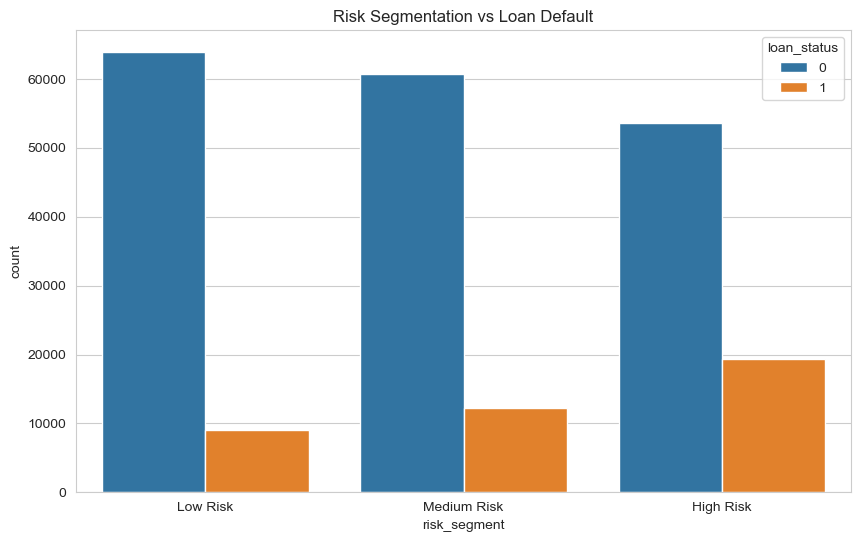

In [18]:
df["risk_segment"] = pd.qcut(
    df["credit_risk_score"],
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

plt.figure()
sns.countplot(
    x="risk_segment",
    hue="loan_status",
    data=df
)
plt.title("Risk Segmentation vs Loan Default")
plt.show()

Installment Burden Analysis

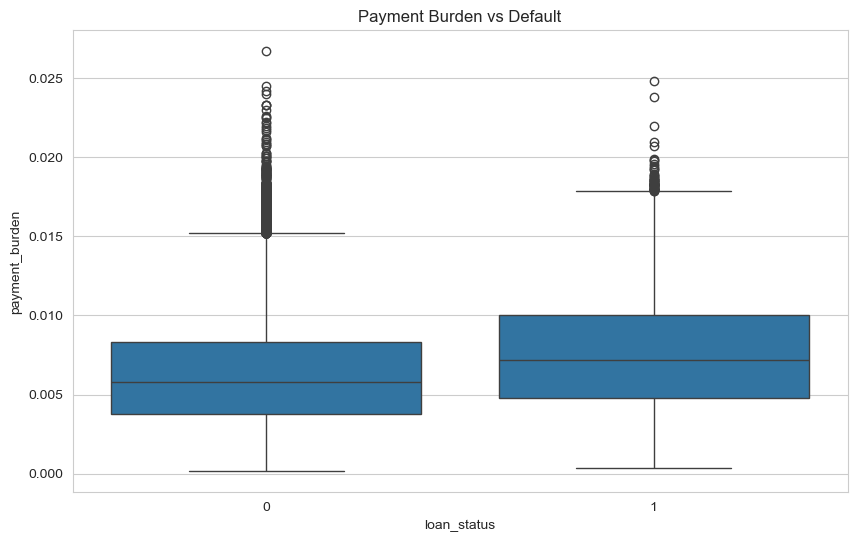

In [19]:
plt.figure()
sns.boxplot(
    x="loan_status",
    y="payment_burden",
    data=df
)
plt.title("Payment Burden vs Default")
plt.show()

Pairplot for Important Variables

In [ ]:
important_features = [
    "loan_amnt",
    "annual_inc",
    "dti",
    "int_rate",
    "credit_risk_score",
    "loan_status"
]

sns.pairplot(df[important_features], hue="loan_status")
plt.show()